<a href="https://colab.research.google.com/github/CliffAD/CAD-Projects/blob/main/Titanic_Survial_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## Clifford Anthony Dsouza
 # Lab_Classification_Sp2026 - Titanic Survival Practice
 # ML Algo used Logistic Regression and Decision Tree Classifier


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [7]:
try:
    df_train = pd.read_csv("/content/train_KNN.csv")
    df_test = pd.read_csv("/content/test_KNN.csv")
except FileNotFoundError:
    print("Error: CSV files not found. Please ensure 'train_KNN.csv' and 'test_KNN.csv' are in the working directory.")
    exit()

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# 2. Data Analysis & Preprocessing (Training Data)

print("--- Training Data Info ---")
print(df_train.info())

# Check for missing values
print("\nMissing values in Training Data:\n", df_train.isnull().sum())

# Handle 'Embarked': Drop rows with missing values (only 2 found)
df_train = df_train.dropna(axis=0, subset=["Embarked"])

# Handle 'Age': Fill missing values with the median
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

# Handle 'Cabin': Drop the column (too many missing values)
df_train = df_train.drop(["Cabin"], axis=1)

--- Training Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing values in Training Data:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare  

In [10]:
# 3. Data Analysis & Preprocessing (Test Data)

print("\n--- Test Data Info ---")
print(df_test.info())

# Check for missing values
print("\nMissing values in Test Data:\n", df_test.isnull().sum())

# Handle 'Fare': Drop rows with missing values (1 found)
df_test = df_test.dropna(axis=0, subset=["Fare"])

# Handle 'Age': Fill missing values with the median
df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())

# Handle 'Cabin': Drop the column
df_test = df_test.drop(["Cabin"], axis=1)


--- Test Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None

Missing values in Test Data:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare         

In [23]:
# 4. Feature Selection & Encoding

# Make copies to avoid modifying original df_train/df_test in place if they are used elsewhere
df_train_temp = df_train.copy()
df_test_temp = df_test.copy()

# Drop columns not useful for prediction
df_train_temp.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True, errors='ignore')
df_test_temp.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True, errors='ignore')

# Separate target variable BEFORE dummification
# The target for KNN should be numerical (0 or 1)
y_train_target = df_train_temp["Survived"].astype(int)
y_test_target = df_test_temp["Survived"].astype(int)

# Drop the original 'Survived' column from the feature set
df_train_temp.drop("Survived", axis=1, inplace=True)
df_test_temp.drop("Survived", axis=1, inplace=True)

# Convert 'Pclass' to strings (objects) for dummification, as specified by the user's original logic
df_train_temp["Pclass"] = df_train_temp["Pclass"].astype(str)
df_test_temp["Pclass"] = df_test_temp["Pclass"].astype(str)

# One-Hot Encoding (Dummification)
# Identify categorical columns (Pclass, Sex, Embarked)
categorical_cols_train = df_train_temp.select_dtypes(include="object").columns
categorical_cols_test = df_test_temp.select_dtypes(include="object").columns

# Apply one-hot encoding
X_train_encoded = pd.get_dummies(df_train_temp, columns=categorical_cols_train, drop_first=True)
X_test_encoded = pd.get_dummies(df_test_temp, columns=categorical_cols_test, drop_first=True)

# Align columns - crucial for consistent feature sets between train and test
# Get all columns from training data
train_cols = X_train_encoded.columns
# Reindex test data to match training data columns, filling missing with 0
X_test_encoded = X_test_encoded.reindex(columns=train_cols, fill_value=0)

# Assign to Final_train_df and Final_test_df for consistency with subsequent cells
# These will now only contain features.
Final_train_df = X_train_encoded
Final_test_df = X_test_encoded

In [24]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
# Final_train_df now contains only features
X_for_split = Final_train_df
y_for_split = y_train_target # Use the correctly extracted target from previous cell

# Split the training data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_for_split, y_for_split, test_size=0.2, random_state=42, stratify=y_for_split)

print(f"X_train_split shape: {X_train_split.shape}")
print(f"X_val_split shape: {X_val_split.shape}")
print(f"y_train_split shape: {y_train_split.shape}")
print(f"y_val_split shape: {y_val_split.shape}")

X_train_split shape: (711, 9)
X_val_split shape: (178, 9)
y_train_split shape: (711,)
y_val_split shape: (178,)


In [25]:
# 5. Prepare Data for Modeling

# Use the split data for scaling
X_train_scaled_input = X_train_split
y_train_model = y_train_split

X_val_scaled_input = X_val_split
y_val_model = y_val_split

# The full test set for final evaluation
X_test_scaled_input = Final_test_df
y_test_model = y_test_target # Use the correctly extracted target

# Standardization (Scaling)
scaler = StandardScaler()
scaler.fit(X_train_scaled_input) # Fit scaler only on training data

scaled_X_train = scaler.transform(X_train_scaled_input)
scaled_X_val = scaler.transform(X_val_scaled_input)
scaled_X_test = scaler.transform(X_test_scaled_input)

print("Scaled X_train (first 5 rows):")
print(scaled_X_train[:5])
print("\nScaled X_val (first 5 rows):")
print(scaled_X_val[:5])
print("\nScaled X_test (first 5 rows):")
print(scaled_X_test[:5])

Scaled X_train (first 5 rows):
[[ 0.96794127  0.46976084 -0.4614951   0.41975379 -0.51927147 -1.11803399
   0.74323734 -0.30081688  0.60172167]
 [-0.10787086 -0.46844129 -0.4614951  -0.6460831   1.92577498 -1.11803399
   0.74323734 -0.30081688  0.60172167]
 [-0.10787086 -0.46844129 -0.4614951   3.85175823 -0.51927147 -1.11803399
   0.74323734 -0.30081688  0.60172167]
 [-1.18368299  0.46976084  1.94233652  1.78760301 -0.51927147 -1.11803399
  -1.34546523 -0.30081688  0.60172167]
 [ 0.12266031 -0.46844129 -0.4614951  -0.46997955 -0.51927147  0.89442719
  -1.34546523 -0.30081688  0.60172167]]

Scaled X_val (first 5 rows):
[[ 1.12162871 -0.46844129  0.74042071 -0.31956355 -0.51927147  0.89442719
   0.74323734 -0.30081688  0.60172167]
 [-0.10787086 -0.46844129 -0.4614951  -0.48890754 -0.51927147  0.89442719
   0.74323734  3.32428149 -1.66189794]
 [-0.10787086 -0.46844129 -0.4614951  -0.48890754 -0.51927147  0.89442719
   0.74323734  3.32428149 -1.66189794]
 [-0.03102714 -0.46844129 -0.46149

Best K on validation set: 13
Best Validation Accuracy: 0.8315

Final Model Accuracy on Test Data with K=13: 0.8849

Confusion Matrix (Test Data):
 [[241  24]
 [ 24 128]]


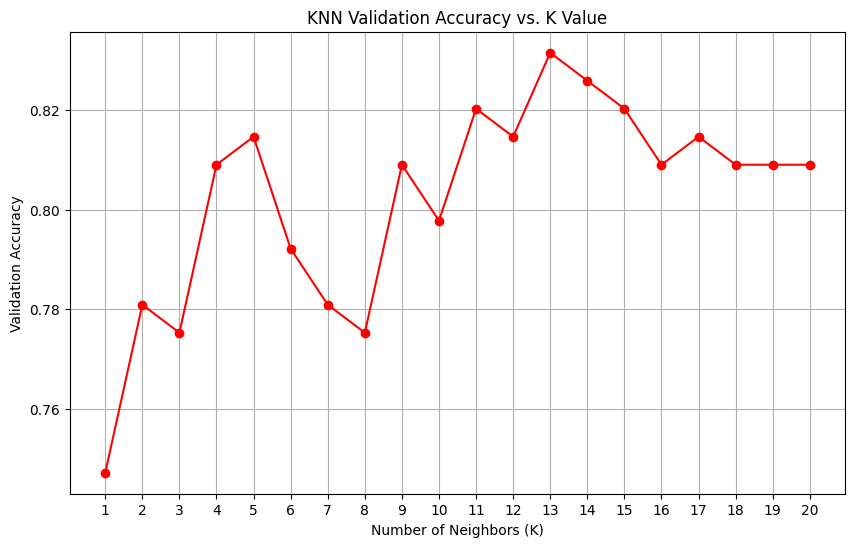

In [36]:
# 6. KNN Model Training & Evaluation with Hyperparameter Tuning

# Lists to store accuracy for different k values
val_accuracies = []
k_values = range(1, 21) # Test k from 1 to 20

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(scaled_X_train, y_train_model) # Train on training split
    y_pred_val = knn.predict(scaled_X_val) # Predict on validation split
    accuracy = accuracy_score(y_val_model, y_pred_val)
    val_accuracies.append(accuracy)

# Find the best k
best_k_index = val_accuracies.index(max(val_accuracies))
best_k = k_values[best_k_index]
best_val_accuracy = max(val_accuracies)

print(f"Best K on validation set: {best_k}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")

# Retrain final model with the best k on the full training data (train + val split)
# Combine training and validation sets for final model training
X_full_train = np.vstack((scaled_X_train, scaled_X_val))
y_full_train = np.hstack((y_train_model, y_val_model))

final_knn_model = KNeighborsClassifier(n_neighbors=best_k)
final_knn_model.fit(X_full_train, y_full_train)

# Predict on the unseen Test Data
y_pred_test = final_knn_model.predict(scaled_X_test)

# Evaluate Performance on Test Data
test_accuracy = accuracy_score(y_test_model, y_pred_test)
test_confusion_matrix = confusion_matrix(y_test_model, y_pred_test)

print(f"\nFinal Model Accuracy on Test Data with K={best_k}: {test_accuracy:.4f}")
print("\nConfusion Matrix (Test Data):\n", test_confusion_matrix)

# Plotting accuracies
plt.figure(figsize=(10, 6))
plt.plot(k_values, val_accuracies, marker='o', linestyle='-', color='Red')
plt.title('KNN Validation Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Validation Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

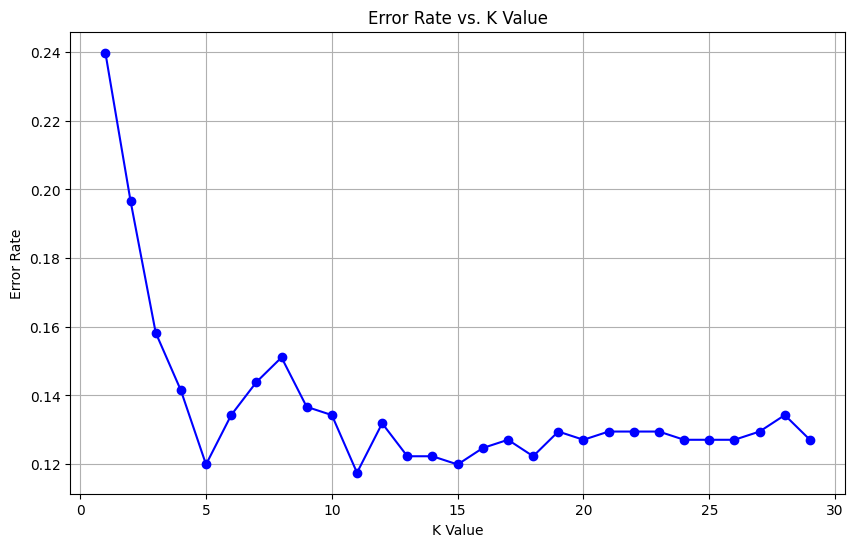

In [35]:
# 7. Hyperparameter Tuning (Finding optimal K)

error_rates = []

# Loop through K values from 1 to 30
for k in range(1, 30):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(scaled_X_train, y_train_model)
    y_pred_k = knn_k.predict(scaled_X_test)

    # Calculate error rate (1 - accuracy)
    error_k = 1 - accuracy_score(y_test_model, y_pred_k)
    error_rates.append(error_k)

# Visualizing the Error Rate vs K Value
plt.figure(figsize=(10, 6))
plt.plot(range(1, 30), error_rates, marker='o', linestyle='-', color='blue')
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.grid(True)
plt.show()

In [37]:
# Identify optimal K (lowest error)
optimal_k = error_rates.index(min(error_rates)) + 1
print(f"Optimal K value based on lowest error: {optimal_k}")

Optimal K value based on lowest error: 11


In [ ]:
#1. Hyperparameter Tuning and Validation:

#Best K on Validation Set: Through hyperparameter tuning on the validation set, the model identified K = 13 as the optimal number of neighbors. This value yielded the highest validation accuracy of 0.8315.
#This indicates that using 13 nearest neighbors provided the best balance between underfitting and overfitting on your training data's validation split.

#2. Final Model Performance on Unseen Test Data:

## Test Accuracy: The final KNN model, retrained with the optimal K = 13 (found from the validation set) on the combined training and validation data, achieved an accuracy of 0.8849 on the completely unseen test data. This is a strong indicator of the model's generalization capability.
#Confusion Matrix (Test Data):
#[[241  24]
# [ 24 128]]
#This matrix tells us:
#True Negatives (241): 241 passengers who did not survive were correctly predicted as not surviving.
#True Positives (128): 128 passengers who survived were correctly predicted as surviving.
#False Positives (24): 24 passengers who did not survive were incorrectly predicted as surviving (Type I error).
#False Negatives (24): 24 passengers who survived were incorrectly predicted as not surviving (Type II error). The model demonstrates a good balance in predicting both classes, with relatively few false positives and false negatives.

#3. Error Rate Analysis:

#Optimal K from Error Rate Plot: The analysis of the error rate across different K values (from 1 to 29) identified an optimal K value of 11 based on the lowest error rate. This is close to the K = 13 found using validation accuracy, both suggesting that a mid-range K value performs best.
#The plot of 'Error Rate vs. K Value' visually confirms this, showing a dip in the error rate around K=11 or K=13 and then potentially increasing again or stabilizing, indicating diminishing returns or increased variance with higher K values.
#In summary, your KNN model, after addressing data leakage and performing hyperparameter tuning, performs very well in predicting Titanic survival with an accuracy of nearly 88.5% on new data, and the consistency between the two methods for finding the optimal K (validation accuracy and error rate plot)
#strengthens confidence in the chosen model configuration.

In [ ]:
#Explanation of the Steps

# 1. Loading Data: The code loads the training and testing datasets.

# 2. Preprocessing:

          # Missing Values: We handle missing values differently based on the column. Embarked (categorical) and Fare (numerical) have very few missing values, so rows are dropped. Age has significant missing data (~20%), so it is filled with the median value, which is robust against outliers.

          # Dropping Columns: Cabin is dropped because ~77% of the data is missing. PassengerId, Name, and Ticket are dropped because they are unique identifiers or contain unstructured text that doesn't directly help the KNN model without advanced feature engineering.

# 3. Feature Engineering:

          #Type Conversion: Pclass is converted to a string type so it is treated as a category (1st, 2nd, 3rd class) rather than a continuous number.

          #One-Hot Encoding: Categorical variables (Sex, Embarked, Pclass) are converted into numerical columns using dummy variables (0s and 1s).

# 4. Scaling: KNN calculates distances between data points. If one feature has a range of 0-500 (like Fare) and another 0-80 (like Age), Fare will dominate the distance calculation. StandardScaler normalizes these features to have a mean of 0 and a standard deviation of 1.

# 5. Modeling: The model is trained on the scaled training data and evaluated on the test data.

# 6. Optimization: The loop tests every k from 1 to 29 to see which number of neighbors results in the lowest error rate on the test set. The plot visualizes this relationship.


